In [1]:
import keras
keras.__version__

'3.12.1'

## Classifying movie reviews: a binary classification example

This project focuses on binary sentiment classification using the IMDB movie reviews dataset. The goal is to classify each review as either positive or negative based on its textual content. A simple neural network model was built and trained to learn patterns in the reviews and predict their sentiment.

## loading The IMDB dataset

The IMDB dataset was loaded as a standard benchmark for binary text classification. It contains movie reviews labeled as positive or negative. After loading the dataset, the reviews and labels were separated into training and testing sets for model development and evaluation.


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

file_path = "C:\\Users\\User\\Desktop\\ml\\kimia course\\IMDB Dataset.csv"
df = pd.read_csv(file_path)

texts = df['review'].values
labels = df['sentiment'].values
labels_num = np.array([1 if label == 'positive' else 0 for label in labels])

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts, labels_num, test_size=0.2, random_state=42
)

max_words = 10000
tokenizer = Tokenizer(num_words=max_words, oov_token=2) 
tokenizer.fit_on_texts(train_texts)

train_data = tokenizer.texts_to_sequences(train_texts)
test_data = tokenizer.texts_to_sequences(test_texts)
train_data = [[1] + sequence for sequence in train_data]
test_data = [[1] + sequence for sequence in test_data]
maxlen = 256
train_data = pad_sequences(train_data, maxlen=maxlen, padding='post', truncating='post')
test_data = pad_sequences(test_data, maxlen=maxlen, padding='post', truncating='post')

print("train_data shape:", train_data.shape)
print("test_data shape:", test_data.shape)
print("train_labels shape:", train_labels.shape)
print("test_labels shape:", test_labels.shape)


train_data shape: (40000, 256)
test_data shape: (10000, 256)
train_labels shape: (40000,)
test_labels shape: (10000,)


##  Data Preprocessing

Before training the model, the raw text data was converted into a numerical format suitable for neural network input. The reviews were vectorized into fixed-size representations so that all samples had the same input dimension. This preprocessing step made it possible to feed text data into a fully connected neural network.

In [18]:
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.  
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

## Building network

A simple feedforward neural network was designed for this classification task. The model consisted of two hidden layers with ReLU activation functions and a final output layer with sigmoid activation. This architecture was chosen because the problem is a binary classification task.

In [ ]:
from keras import models
from keras import layers
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

c:\Users\User\tf-env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Model compilation
The model was compiled using the binary cross-entropy loss function, which is appropriate for binary classification problems. An optimizer was also used to update the network weights during training, and accuracy was selected as the evaluation metric.

In [22]:
from keras import losses
from keras import metrics
from keras import optimizers
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

## Validation

Validation was used to monitor the model’s performance on unseen data during training. This helped determine whether the model was learning effectively or starting to overfit the training set. Comparing training and validation results provided insight into the model’s generalization ability.

In [23]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

## training the model
The model was trained for 20 epochs using mini-batches of size 512. During training, both loss and accuracy were recorded for the training and validation sets. These values were later used to analyze the learning behavior of the model.



In [24]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - binary_accuracy: 0.8213 - loss: 0.4472 - val_binary_accuracy: 0.8676 - val_loss: 0.3368
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - binary_accuracy: 0.8967 - loss: 0.2749 - val_binary_accuracy: 0.8691 - val_loss: 0.3143
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - binary_accuracy: 0.9155 - loss: 0.2258 - val_binary_accuracy: 0.8813 - val_loss: 0.2883
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - binary_accuracy: 0.9279 - loss: 0.1971 - val_binary_accuracy: 0.8816 - val_loss: 0.2980
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - binary_accuracy: 0.9370 - loss: 0.1743 - val_binary_accuracy: 0.8777 - val_loss: 0.3113
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - binary_accuracy: 0.9419 - loss: 0.1589 - val_binary_accuracy: 0.8706 - val_loss: 0.3384
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - binary_accuracy: 0.9496 - loss: 0.1437 - val_binary_accuracy: 0.8738 - val_loss: 0.3422
Epoch 8/20
5

In [25]:
history_dict = history.history
history_dict.keys()

dict_keys(['binary_accuracy', 'loss', 'val_binary_accuracy', 'val_loss'])

## plotting accuracy and loss 
The training process was visualized using accuracy and loss curves. These plots made it easier to compare the model’s performance on the training and validation sets. The graphs showed how the model improved over time and whether overfitting occurred.

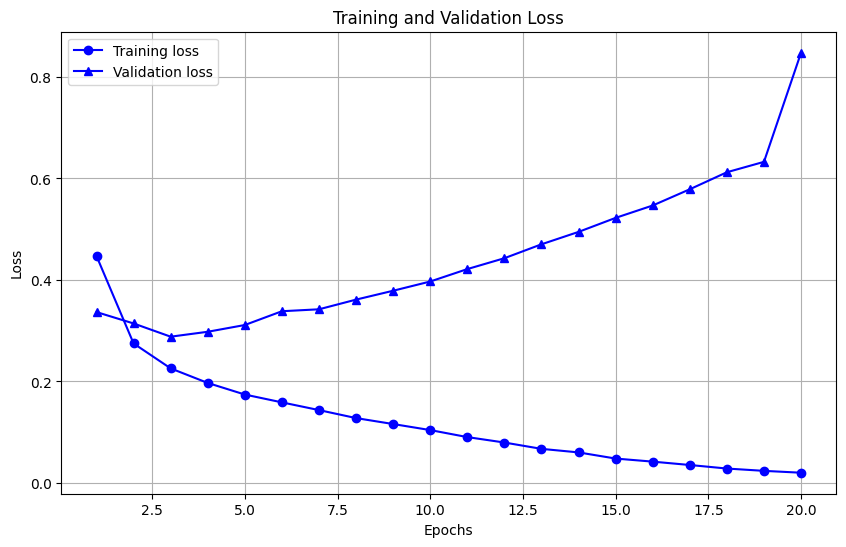

In [29]:

acc = history.history.get('accuracy') or history.history.get('binary_accuracy')
val_acc = history.history.get('val_accuracy') or history.history.get('val_binary_accuracy')
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'bo-', label='Training loss')
plt.plot(epochs, val_loss, 'b^-', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


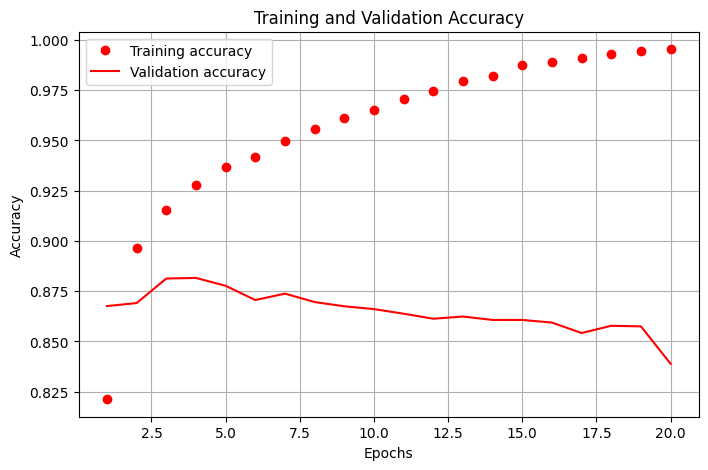

In [36]:
acc_values = history_dict['binary_accuracy']
val_acc_values = history_dict['val_binary_accuracy']
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
plt.figure(figsize=(8, 5))
plt.plot(epochs, acc_values, 'ro', label='Training accuracy')
plt.plot(epochs, val_acc_values, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## retraining the model
After analyzing the initial results, the model was retrained to improve performance and confirm the stability of the learning process. Retraining helped evaluate whether the network could achieve better generalization with the selected configuration.

In [37]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

c:\Users\User\tf-env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.8264 - loss: 0.4169
Epoch 2/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8967 - loss: 0.2650
Epoch 3/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9130 - loss: 0.2252
Epoch 4/4
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9215 - loss: 0.2053
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8784 - loss: 0.3136


## prediction on new data
After training, the model was used to generate predictions on new unseen reviews. The output values represented probabilities, which were converted into positive or negative labels using a threshold. This demonstrated how the trained network can be applied in practice.

In [38]:
model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[0.91008383],
       [0.98585844],
       [0.04561477],
       ...,
       [0.95085037],
       [0.10284188],
       [0.8115768 ]], shape=(10000, 1), dtype=float32)

In [ ]:
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8784 - loss: 0.3136


[0.3136321008205414, 0.8784000277519226]

##  Experimental Section

* Task1 : Try to use 1 or 3 hidden layers and see how it affects test accuracy.
* Task2 : Try to use layers with more hidden units or less hidden units: 32 units, 64 units...
* Task3 : Try to use the `mse` loss function instead of `binary_crossentropy`.
* Task4 : Try to use the `tanh` activation (an activation that was popular in the early days of neural networks) instead of `relu`.


##  1)Effect of Increasing the Number of Layers :

In this experiment, different neural network architectures with various numbers of layers were tested on the IMDB sentiment analysis dataset. The objective was to analyze the effect of increasing the number of layers on model performance.

## using 1 hidden layer :

In [47]:
model1= models.Sequential()
model1.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model1.add(layers.Dense(1, activation='sigmoid'))

c:\Users\User\tf-env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
model1.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

In [49]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [50]:
history = model1.fit(partial_x_train,
                    partial_y_train,
                    epochs=4,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 45ms/step - binary_accuracy: 0.8169 - loss: 0.4806 - val_binary_accuracy: 0.8658 - val_loss: 0.3664
Epoch 2/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - binary_accuracy: 0.8854 - loss: 0.3154 - val_binary_accuracy: 0.8717 - val_loss: 0.3167
Epoch 3/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - binary_accuracy: 0.9035 - loss: 0.2628 - val_binary_accuracy: 0.8793 - val_loss: 0.2919
Epoch 4/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - binary_accuracy: 0.9148 - loss: 0.2331 - val_binary_accuracy: 0.8819 - val_loss: 0.2855


In [52]:
model1.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[0.43924722],
       [0.9317659 ],
       [0.08035891],
       ...,
       [0.9163896 ],
       [0.11651439],
       [0.79010534]], shape=(10000, 1), dtype=float32)

In [51]:
model1.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8819 - loss: 0.2867


[0.2867065370082855, 0.8819000124931335]

## using 3 hidden layers

In [53]:
model2= models.Sequential()
model2.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model2.add(layers.Dense(16, activation='relu'))
model2.add(layers.Dense(16, activation='relu'))
model2.add(layers.Dense(1, activation='sigmoid'))

c:\Users\User\tf-env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
model2.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

In [55]:
history = model2.fit(partial_x_train,
                    partial_y_train,
                    epochs=4,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - binary_accuracy: 0.7918 - loss: 0.5006 - val_binary_accuracy: 0.8548 - val_loss: 0.3606
Epoch 2/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - binary_accuracy: 0.8915 - loss: 0.2932 - val_binary_accuracy: 0.8814 - val_loss: 0.2919
Epoch 3/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - binary_accuracy: 0.9122 - loss: 0.2354 - val_binary_accuracy: 0.8815 - val_loss: 0.2928
Epoch 4/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - binary_accuracy: 0.9248 - loss: 0.2031 - val_binary_accuracy: 0.8818 - val_loss: 0.2979


In [56]:
model2.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[0.5888766 ],
       [0.9870648 ],
       [0.03779956],
       ...,
       [0.9608453 ],
       [0.05635479],
       [0.8497253 ]], shape=(10000, 1), dtype=float32)

In [58]:
model2.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8791 - loss: 0.3014


[0.3014428913593292, 0.8791000247001648]

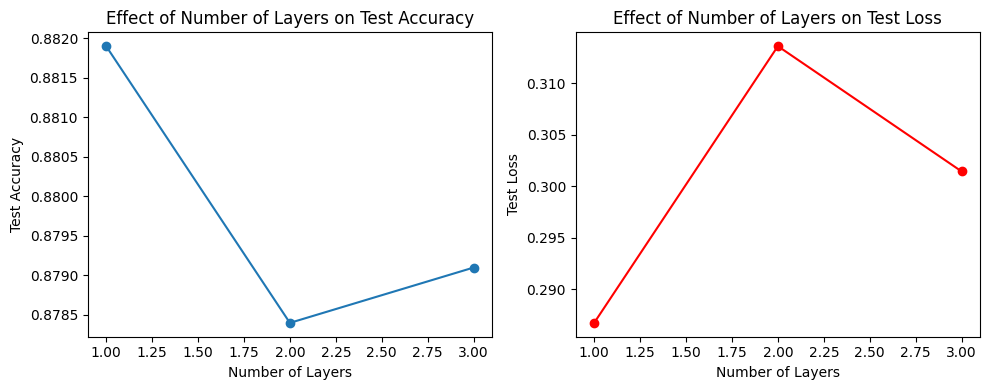

In [80]:

layers = [1, 2, 3]
test_accuracy = [0.8819000124931335, 0.8784000277519226, 0.8791000247001648]
test_loss = [0.2867065370082855, 0.3136321008205414 , 0.3014428913593292 ]

plt.figure(figsize=(10,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(layers, test_accuracy, marker='o')
plt.title("Effect of Number of Layers on Test Accuracy")
plt.xlabel("Number of Layers")
plt.ylabel("Test Accuracy")

# Loss plot
plt.subplot(1,2,2)
plt.plot(layers, test_loss, marker='o', color='red')
plt.title("Effect of Number of Layers on Test Loss")
plt.xlabel("Number of Layers")
plt.ylabel("Test Loss")

plt.tight_layout()
plt.show()


## Result :
In this experiment, the effect of increasing the number of hidden layers was investigated. After training deeper models, the results showed that increasing the number of layers did not improve the test performance. In some cases, the model accuracy decreased and the loss increased. This behavior may indicate overfitting, where the model learns the training data too well but performs poorly on unseen data.
## best number of layers : 1 

## 2) Effect of Increasing the Number of Units

In this experiment, the effect of increasing the number of units in the neural network layers was examined using the IMDB sentiment analysis dataset. The goal was to analyze how changing the model capacity influences its performance.

## using more hidden unit (64):

In [61]:
from keras import models
from keras import layers
model3= models.Sequential()
model3.add(layers.Dense(64, activation='relu', input_shape=(10000,)))
model3.add(layers.Dense(64, activation='relu'))
model3.add(layers.Dense(1, activation='sigmoid'))

c:\Users\User\tf-env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [62]:
model3.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

In [64]:
history = model3.fit(partial_x_train,
                    partial_y_train,
                    epochs=4,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - binary_accuracy: 0.7990 - loss: 0.4391 - val_binary_accuracy: 0.8699 - val_loss: 0.3199
Epoch 2/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - binary_accuracy: 0.8900 - loss: 0.2717 - val_binary_accuracy: 0.8626 - val_loss: 0.3343
Epoch 3/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - binary_accuracy: 0.9098 - loss: 0.2280 - val_binary_accuracy: 0.8791 - val_loss: 0.2960
Epoch 4/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - binary_accuracy: 0.9246 - loss: 0.1957 - val_binary_accuracy: 0.8640 - val_loss: 0.3484


In [65]:
model3.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[0.39972025],
       [0.90303206],
       [0.00854214],
       ...,
       [0.93639165],
       [0.02135692],
       [0.76039845]], shape=(10000, 1), dtype=float32)

In [66]:
model3.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - binary_accuracy: 0.8609 - loss: 0.3552


[0.35523521900177, 0.8608999848365784]

## using more hidden units (32) :

In [ ]:
from keras import models
from keras import layers
model4= models.Sequential()
model4.add(layers.Dense(32, activation='relu', input_shape=(10000,)))
model4.add(layers.Dense(32, activation='relu'))
model4.add(layers.Dense(1, activation='sigmoid'))

c:\Users\User\tf-env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
model4.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

In [70]:
history = model4.fit(partial_x_train,
                    partial_y_train,
                    epochs=4,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - binary_accuracy: 0.8080 - loss: 0.4460 - val_binary_accuracy: 0.8738 - val_loss: 0.3163
Epoch 2/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - binary_accuracy: 0.8929 - loss: 0.2756 - val_binary_accuracy: 0.8768 - val_loss: 0.2990
Epoch 3/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - binary_accuracy: 0.9104 - loss: 0.2306 - val_binary_accuracy: 0.8675 - val_loss: 0.3222
Epoch 4/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - binary_accuracy: 0.9238 - loss: 0.1996 - val_binary_accuracy: 0.8795 - val_loss: 0.2991


In [71]:
model4.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[0.6606249 ],
       [0.98421454],
       [0.02005211],
       ...,
       [0.97273386],
       [0.14538506],
       [0.8413309 ]], shape=(10000, 1), dtype=float32)

In [72]:
model4.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8777 - loss: 0.3008


[0.3007589876651764, 0.8776999711990356]

## using less hidden unit (8) :

In [73]:
from keras import models
from keras import layers
model5= models.Sequential()
model5.add(layers.Dense(8, activation='relu', input_shape=(10000,)))
model5.add(layers.Dense(8, activation='relu'))
model5.add(layers.Dense(1, activation='sigmoid'))

c:\Users\User\tf-env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [74]:
model5.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

In [75]:
history = model5.fit(partial_x_train,
                    partial_y_train,
                    epochs=4,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 47ms/step - binary_accuracy: 0.8098 - loss: 0.4932 - val_binary_accuracy: 0.8638 - val_loss: 0.3747
Epoch 2/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - binary_accuracy: 0.8877 - loss: 0.3119 - val_binary_accuracy: 0.8768 - val_loss: 0.3064
Epoch 3/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - binary_accuracy: 0.9075 - loss: 0.2495 - val_binary_accuracy: 0.8838 - val_loss: 0.2842
Epoch 4/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - binary_accuracy: 0.9203 - loss: 0.2168 - val_binary_accuracy: 0.8847 - val_loss: 0.2844


In [76]:
model5.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


array([[0.4312497 ],
       [0.97447646],
       [0.04955789],
       ...,
       [0.9619478 ],
       [0.07339415],
       [0.8049897 ]], shape=(10000, 1), dtype=float32)

In [77]:
model5.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8813 - loss: 0.2882


[0.2881799340248108, 0.8812999725341797]

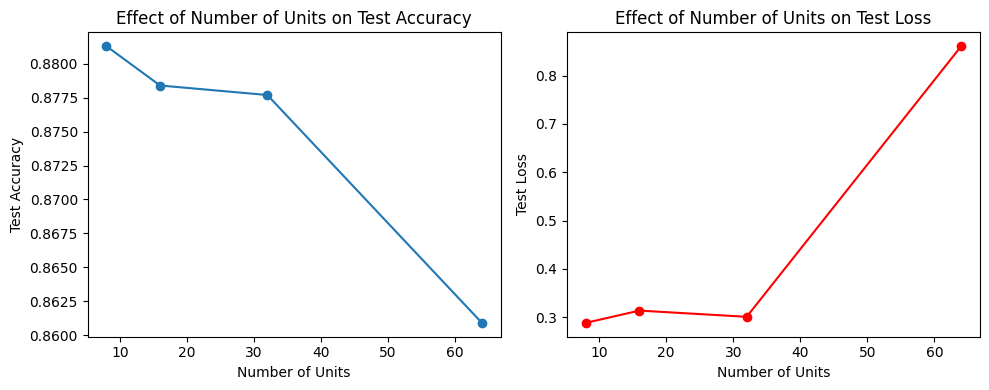

In [82]:

layers = [8, 16, 32 , 64]
Test_accuracy = [0.8812999725341797, 0.8784000277519226, 0.8776999711990356 , 0.8608999848365784 ]
Test_loss = [0.2881799340248108,0.3136321008205414 ,0.3007589876651764, 0.8608999848365784]

plt.figure(figsize=(10,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(layers, Test_accuracy, marker='o')
plt.title("Effect of Number of Units on Test Accuracy")
plt.xlabel("Number of Units")
plt.ylabel("Test Accuracy")

# Loss plot
plt.subplot(1,2,2)
plt.plot(layers, Test_loss, marker='o', color='red')
plt.title("Effect of Number of Units on Test Loss")
plt.xlabel("Number of Units")
plt.ylabel("Test Loss")

plt.tight_layout()
plt.show()

## Result : 
Another experiment was performed by increasing the number of units in the hidden layers. Although larger models have greater learning capacity, the results showed a slight decrease in performance on the test set. This suggests that simply increasing model complexity does not always improve generalization.
## Best number of units : 8

## 3) Comparing Loss Functions (binary_crossentropy vs mse)


In this experiment, two different loss functions, Binary Crossentropy and Mean Squared Error (MSE), were compared in order to evaluate their effect on the performance of the neural network model for IMDB sentiment classification.

In [84]:
from keras import models
from keras import layers
model6 = models.Sequential()
model6.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model6.add(layers.Dense(16, activation='relu'))
model6.add(layers.Dense(1, activation='sigmoid'))

c:\Users\User\tf-env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [86]:
from keras import losses
from keras import metrics
from keras import optimizers
model6.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss='mse',
              metrics=[metrics.binary_accuracy])

In [88]:
history = model6.fit(partial_x_train,
                    partial_y_train,
                    epochs=4,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - binary_accuracy: 0.8041 - loss: 0.1586 - val_binary_accuracy: 0.8618 - val_loss: 0.1130
Epoch 2/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - binary_accuracy: 0.8863 - loss: 0.0939 - val_binary_accuracy: 0.8766 - val_loss: 0.0929
Epoch 3/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - binary_accuracy: 0.9051 - loss: 0.0769 - val_binary_accuracy: 0.8815 - val_loss: 0.0887
Epoch 4/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - binary_accuracy: 0.9173 - loss: 0.0675 - val_binary_accuracy: 0.8789 - val_loss: 0.0890


In [94]:
model6.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8794 - loss: 0.0885


[0.08847775310277939, 0.8794000148773193]

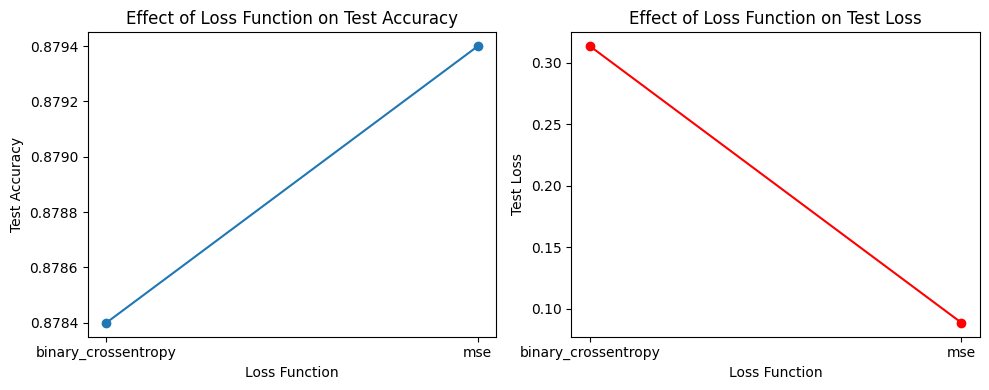

In [95]:
import matplotlib.pyplot as plt

layers = ['binary_crossentropy', 'mse']

test_accuracy = [ 0.8784000277519226,0.8794000148773193]
test_loss = [0.3136321008205414, 0.08847775310277939 ]

plt.figure(figsize=(10,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(layers, test_accuracy, marker='o')
plt.title("Effect of Loss Function on Test Accuracy")
plt.xlabel("Loss Function")
plt.ylabel("Test Accuracy")

# Loss plot
plt.subplot(1,2,2)
plt.plot(layers, test_loss, marker='o', color='red')
plt.title("Effect of Loss Function on Test Loss")
plt.xlabel("Loss Function")
plt.ylabel("Test Loss")

plt.tight_layout()
plt.show()


## Result : 
Two different loss functions were compared in this experiment: binary cross-entropy and mean squared error (MSE). Surprisingly, the model trained with MSE achieved slightly better results in this specific experiment. However, binary cross-entropy is generally considered the standard choice for binary classification problems.
## Beat loss function : MSE

## 4) Comparing Activation Functions (ReLU vs Tanh)

In this experiment, two activation functions, ReLU and Tanh, were compared to evaluate their impact on the performance of the neural network model on the IMDB sentiment analysis dataset.

In [97]:
from keras import models
from keras import layers
model7 = models.Sequential()
model7.add(layers.Dense(16, activation='tanh', input_shape=(10000,)))
model7.add(layers.Dense(16, activation='tanh'))
model7.add(layers.Dense(1, activation='sigmoid'))

c:\Users\User\tf-env\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [98]:
model7.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

In [99]:
history = model7.fit(partial_x_train,
                    partial_y_train,
                    epochs=4,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - binary_accuracy: 0.8227 - loss: 0.4224 - val_binary_accuracy: 0.8750 - val_loss: 0.3101
Epoch 2/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - binary_accuracy: 0.9004 - loss: 0.2591 - val_binary_accuracy: 0.8729 - val_loss: 0.3081
Epoch 3/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - binary_accuracy: 0.9174 - loss: 0.2155 - val_binary_accuracy: 0.8805 - val_loss: 0.2961
Epoch 4/4
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - binary_accuracy: 0.9287 - loss: 0.1891 - val_binary_accuracy: 0.8765 - val_loss: 0.3147


In [100]:
model7.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - binary_accuracy: 0.8755 - loss: 0.3171


[0.3170579969882965, 0.8755000233650208]

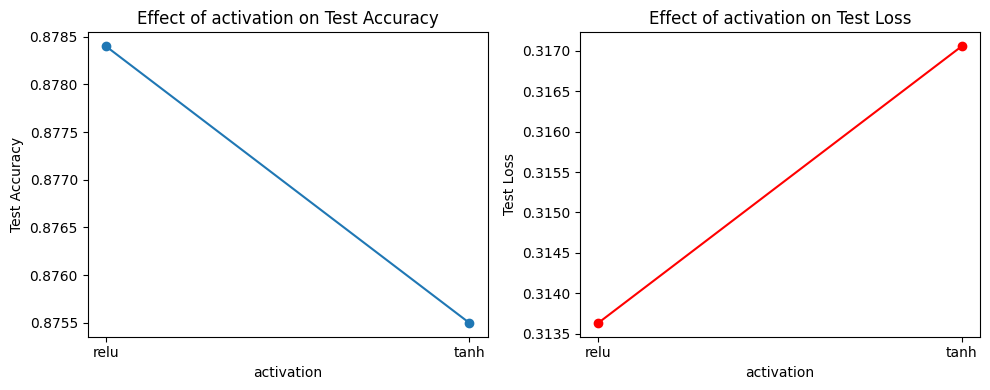

In [101]:
import matplotlib.pyplot as plt

layers = ['relu', 'tanh']

test_accuracy = [ 0.8784000277519226,0.8755000233650208]
test_loss = [0.3136321008205414, 0.3170579969882965 ]

plt.figure(figsize=(10,4))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(layers, test_accuracy, marker='o')
plt.title("Effect of activation on Test Accuracy")
plt.xlabel("activation")
plt.ylabel("Test Accuracy")

# Loss plot
plt.subplot(1,2,2)
plt.plot(layers, test_loss, marker='o', color='red')
plt.title("Effect of activation on Test Loss")
plt.xlabel("activation")
plt.ylabel("Test Loss")

plt.tight_layout()
plt.show()

## Result :
The ReLU and Tanh activation functions were compared to evaluate their impact on model performance. The results showed that the ReLU activation function achieved slightly higher accuracy and lower loss values than Tanh. ReLU also helped the model train more efficiently.

## Best activation : ReLU

## Final Discussion :
Overall, the experiments demonstrated how architectural choices such as the number of layers, number of units, activation functions, and loss functions can affect neural network performance. The results showed that a simpler model sometimes performs better than a more complex one for sentiment analysis tasks.